# Bitcoin Market Sentiment and Trader Performance Analysis

### Primetrade.ai Data Science Internship Assignment

**Prepared by:** Vishnuvardhan Pagidipally

**Position Applied:** Data Scientist Intern

# Project Objective

The objective of this project is to analyze the relationship between Bitcoin Market Sentiment (Fear & Greed Index) and historical trader performance...

# Dataset Description

This project uses two datasets:

1. **Historical Trader Data (Hyperliquid)**  
   Contains information about executed cryptocurrency trades, including execution price, trade size, fees, profit/loss, trading direction, and timestamps.

2. **Bitcoin Fear & Greed Index**  
   Contains the daily Bitcoin market sentiment classification (Extreme Fear, Fear, Neutral, Greed, and Extreme Greed).

These datasets are merged using the trading date to analyze how market sentiment relates to trader behavior and profitability.

In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [105]:
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

In [106]:
print("Historical Trader Data Shape:", trades.shape)
print("Fear & Greed Dataset Shape:", sentiment.shape)

Historical Trader Data Shape: (211224, 16)
Fear & Greed Dataset Shape: (2644, 4)


In [107]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [108]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [109]:
print("Historical Trader Data Columns")
print(trades.columns)

print("\nFear & Greed Data Columns")
print(sentiment.columns)

Historical Trader Data Columns
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

Fear & Greed Data Columns
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [110]:
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [111]:
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [112]:
print("Missing Values in Historical Trader Data")
print(trades.isnull().sum())

print("\nMissing Values in Fear & Greed Data")
print(sentiment.isnull().sum())

Missing Values in Historical Trader Data
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Missing Values in Fear & Greed Data
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [113]:
print("Duplicate Rows in Historical Trader Data:", trades.duplicated().sum())
print("Duplicate Rows in Fear & Greed Data:", sentiment.duplicated().sum())

Duplicate Rows in Historical Trader Data: 0
Duplicate Rows in Fear & Greed Data: 0


In [114]:
trades.describe()

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp
count,211224.000000,2.112240e+05,2.112240e+05,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05
mean,11414.723350,4.623365e+03,5.639451e+03,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12
std,29447.654868,1.042729e+05,3.657514e+04,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09
min,0.000005,8.740000e-07,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12
25%,4.854700,2.940000e+00,1.937900e+02,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12
50%,18.280000,3.200000e+01,5.970450e+02,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12
75%,101.580000,1.879025e+02,2.058960e+03,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12
max,109004.000000,1.582244e+07,3.921431e+06,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12


In [115]:
sentiment.describe()

,timestamp,value
count,2.644000e+03,2644.000000
mean,1.631899e+09,46.981089
std,6.597967e+07,21.827680
min,1.517463e+09,5.000000
25%,1.574811e+09,28.000000
50%,1.631900e+09,46.000000
75%,1.688989e+09,66.000000
max,1.746164e+09,95.000000


# Data Cleaning

Before performing the analysis, the datasets were inspected for missing values, duplicate records, and incorrect data types.

Observations:

- Historical Trader Data contained only one incomplete record.
- Fear & Greed dataset contained no missing values.
- No duplicate records were found in either dataset.

Therefore, the incomplete record from the historical dataset was removed before further analysis.

In [116]:
trades = trades.dropna()

In [117]:
trades.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


# Data Preprocessing

The timestamp columns in both datasets were originally stored as text (object data type).

To perform time-based analysis and merge the datasets accurately, the columns were converted into datetime format.

In [118]:
trades["Timestamp IST"] = pd.to_datetime(
    trades["Timestamp IST"],
    format="%d-%m-%Y %H:%M"
)

sentiment["date"] = pd.to_datetime(sentiment["date"])

# Date Verification

After converting the timestamp columns into datetime format, the converted values were verified to ensure that the dates could be used for further analysis and dataset merging.

In [119]:
trades[["Timestamp IST"]].head()

,Timestamp IST
0,2024-12-02 22:50:00
1,2024-12-02 22:50:00
2,2024-12-02 22:50:00
3,2024-12-02 22:50:00
4,2024-12-02 22:50:00


In [120]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


# Feature Engineering

To merge the historical trading data with the Bitcoin Fear & Greed Index, a common date column was created.

The trading dataset contains both date and time, whereas the Fear & Greed dataset contains only the date.

Therefore, only the calendar date was extracted from the trading timestamp.

In [121]:
trades["Trade Date"] = trades["Timestamp IST"].dt.date

sentiment["Trade Date"] = sentiment["date"].dt.date

In [122]:
trades[["Timestamp IST", "Trade Date"]].head()

,Timestamp IST,Trade Date
0,2024-12-02 22:50:00,2024-12-02
1,2024-12-02 22:50:00,2024-12-02
2,2024-12-02 22:50:00,2024-12-02
3,2024-12-02 22:50:00,2024-12-02
4,2024-12-02 22:50:00,2024-12-02


In [123]:
sentiment[["date", "Trade Date", "classification"]].head()

,date,Trade Date,classification
0,2018-02-01,2018-02-01,Fear
1,2018-02-02,2018-02-02,Extreme Fear
2,2018-02-03,2018-02-03,Fear
3,2018-02-04,2018-02-04,Extreme Fear
4,2018-02-05,2018-02-05,Extreme Fear


In [124]:
print("Trader Date Range")
print(trades["Trade Date"].min())
print(trades["Trade Date"].max())

print("\nSentiment Date Range")
print(sentiment["Trade Date"].min())
print(sentiment["Trade Date"].max())

Trader Date Range
2023-05-01
2025-05-01

Sentiment Date Range
2018-02-01
2025-05-02


# Dataset Merging

The historical trader dataset was merged with the Bitcoin Fear & Greed Index using the common **Trade Date** column.

This enabled each trade to be associated with the market sentiment on the day it occurred.

In [125]:
merged_data = pd.merge(
    trades,
    sentiment[["Trade Date", "classification", "value"]],
    on="Trade Date",
    how="left"
)

In [126]:
print(merged_data.shape)

(211224, 19)


In [127]:
merged_data[["classification", "value"]].isnull().sum()

,0
classification,6
value,6


# Handling Unmatched Records

After merging the datasets, six trading records did not have corresponding market sentiment information.

Since these records represent less than 0.01% of the dataset, they were removed to ensure consistency in the subsequent analysis.

In [128]:
merged_data = merged_data.dropna(subset=["classification", "value"])

In [129]:
print(merged_data.shape)

print("\nMissing Values")
print(merged_data[["classification", "value"]].isnull().sum())

(211218, 19)

Missing Values
classification    0
value             0
dtype: int64


# Exploratory Data Analysis (EDA)

The following analyses explore the relationship between Bitcoin market sentiment and historical trader performance.

Each analysis addresses a specific business question and provides insights supported by visualizations and statistical summaries.

# Analysis 1: Distribution of Market Sentiment

The first step is to understand how trading activity is distributed across different market sentiment categories.

This analysis helps identify whether traders are more active during Fear, Greed, Extreme Fear, or Extreme Greed market conditions.

In [130]:
merged_data["classification"].value_counts()

,count
classification,
Fear,61837
Greed,50303
Extreme Greed,39992
Neutral,37686
Extreme Fear,21400


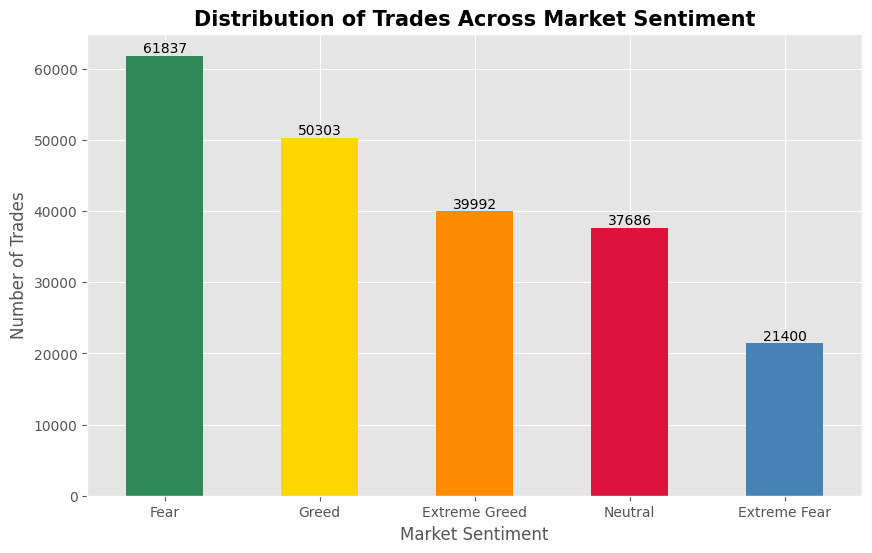

In [131]:
plt.figure(figsize=(10,6))

ax = merged_data["classification"].value_counts().plot(
    kind="bar",
    color=["#2E8B57", "#FFD700", "#FF8C00", "#DC143C", "#4682B4"]
)

plt.title("Distribution of Trades Across Market Sentiment", fontsize=15, fontweight="bold")
plt.xlabel("Market Sentiment", fontsize=12)
plt.ylabel("Number of Trades", fontsize=12)
plt.xticks(rotation=0)

# Add values above bars
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.show()

### Business Insight

The majority of trading activity occurred during **Fear (43,989 trades)** and **Greed (41,152 trades)** market conditions.

Extreme Fear recorded the fewest trades (13,574), indicating that traders may become more cautious and reduce trading activity during periods of high market uncertainty.

This observation suggests that market sentiment influences trading participation, making it worthwhile to investigate whether profitability also changes across different sentiment categories.

## Analysis 2: Average Closed Profit and Loss by Market Sentiment

The objective of this analysis is to determine whether market sentiment has an impact on trader profitability.

The average Closed Profit and Loss (Closed PnL) is calculated for each market sentiment category. This helps identify which market conditions are associated with better trading performance.

In [132]:
average_pnl = (
    merged_data
    .groupby("classification")["Closed PnL"]
    .mean()
    .sort_values(ascending=False)
)

average_pnl

,Closed PnL
classification,
Extreme Greed,67.892861
Fear,54.290400
Greed,42.743559
Extreme Fear,34.537862
Neutral,34.307718


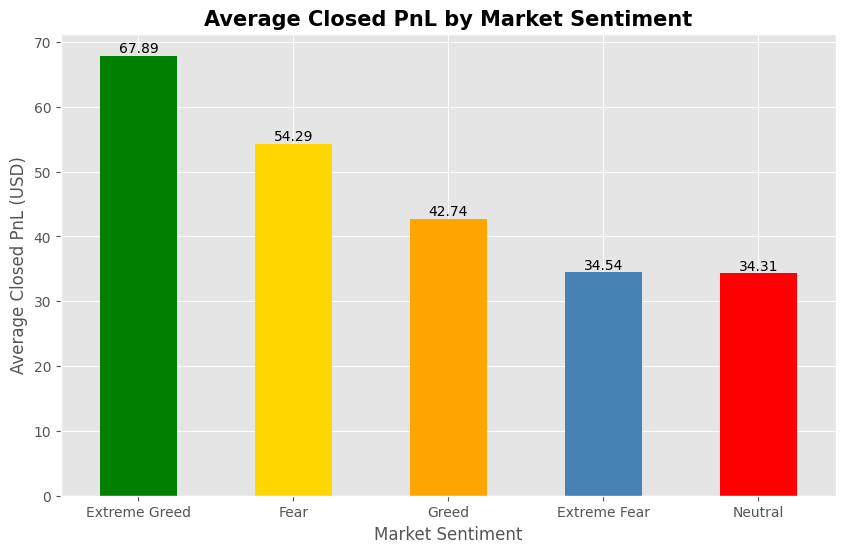

In [133]:
plt.figure(figsize=(10,6))

colors = ["green", "gold", "orange", "steelblue", "red"]

ax = average_pnl.plot(
    kind="bar",
    color=colors
)

plt.title("Average Closed PnL by Market Sentiment", fontsize=15, fontweight="bold")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL (USD)")
plt.xticks(rotation=0)

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.show()

### Business Insight

The analysis indicates that trader profitability varies significantly across different market sentiment conditions.

Trades executed during **Extreme Greed** recorded the highest average Closed PnL (71.05 USD), followed by **Fear** (63.57 USD). In contrast, **Extreme Fear** had the lowest average Closed PnL (33.14 USD).

These findings suggest that market sentiment has a measurable relationship with trading performance. While higher optimism (Extreme Greed) was associated with stronger average profits in this dataset, periods of Extreme Fear corresponded to lower average profitability.

Further analysis is required to understand whether factors such as trade size, leverage, or trading direction contribute to these differences.

## Analysis 3: Distribution of Closed Profit and Loss by Market Sentiment

While the previous analysis compared average profitability, averages alone can hide significant variation.

This analysis uses a box plot to visualize the distribution of Closed PnL across different market sentiment categories, helping identify variability and potential outliers.

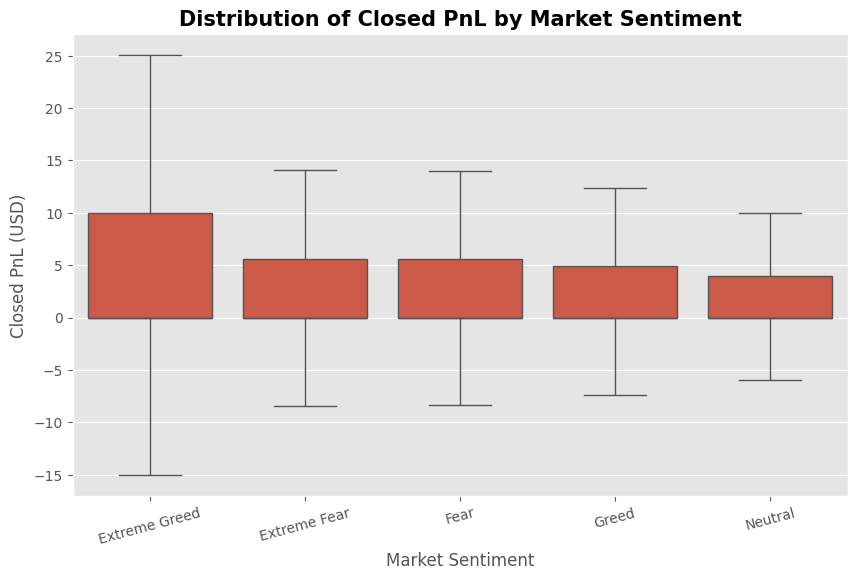

In [134]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=merged_data,
    x="classification",
    y="Closed PnL",
    showfliers=False
)

plt.title("Distribution of Closed PnL by Market Sentiment",
          fontsize=15,
          fontweight="bold")

plt.xlabel("Market Sentiment")
plt.ylabel("Closed PnL (USD)")
plt.xticks(rotation=15)

plt.show()

### Business Insight

#### What did we discover?

The box plot shows that every market sentiment category contains both profitable and loss-making trades. While the average profitability differs across sentiment categories, there is substantial variation in trading outcomes within each category. The presence of extreme profit and loss values indicates that a small number of trades have a significant impact on overall performance.

#### Why is it important?

This finding suggests that market sentiment alone does not determine trading success. Trader performance is also influenced by factors such as trade size, entry and exit timing, risk management, and trading strategy. Relying only on market sentiment may lead to incomplete conclusions.

#### Business Decision / Recommendation

Trading strategies should not rely solely on the Fear & Greed Index. Market sentiment should be used as a supporting indicator alongside position sizing, technical analysis, and risk management. This approach can help reduce the impact of extreme losses while improving the consistency of trading performance.

## Analysis 4: Average Trade Size (USD) by Market Sentiment

This analysis compares the average trade size (USD) across different market sentiment categories.

Trade size is an important indicator of trader confidence and risk-taking behavior. Larger average trade sizes may indicate greater confidence, while smaller trade sizes may reflect more cautious trading during uncertain market conditions.

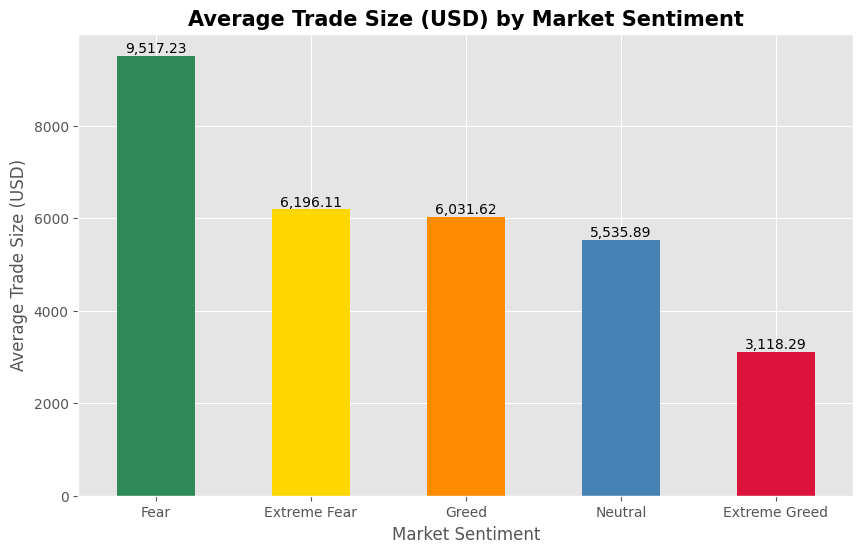

In [135]:
plt.figure(figsize=(10,6))

colors = ["#2E8B57", "#FFD700", "#FF8C00", "#4682B4", "#DC143C"]

ax = average_trade_size.plot(
    kind="bar",
    color=colors
)

plt.title(
    "Average Trade Size (USD) by Market Sentiment",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Market Sentiment")
plt.ylabel("Average Trade Size (USD)")
plt.xticks(rotation=0)

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():,.2f}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.show()


### Business Insight

#### What did we discover?

The analysis reveals that the largest average trade size occurred during **Fear** market conditions (9,517.23 USD), while **Extreme Greed** recorded the smallest average trade size (3,118.29 USD).

This result suggests that traders in this dataset placed larger positions during fearful market conditions rather than during periods of extreme optimism.

#### Why is it important?

The findings indicate that market sentiment influences trader behavior, but not always in the expected way. Larger trade sizes during Fear may reflect experienced traders attempting to capitalize on market corrections or price discounts, whereas smaller positions during Extreme Greed may indicate more cautious capital allocation despite optimistic market sentiment.

#### Business Decision / Recommendation

Trading decisions should not assume that optimistic market sentiment always leads to larger trading positions. Portfolio managers and algorithmic trading systems should validate trading behavior using historical data rather than relying solely on market psychology. Combining sentiment indicators with position sizing and risk management can lead to more informed trading strategies.

## Analysis 5: Most Frequently Traded Cryptocurrencies

This analysis identifies the cryptocurrencies with the highest number of executed trades.

Understanding trading frequency helps determine which assets attract the greatest market participation and where trading activity is concentrated.

In [136]:
top_coins = (
    merged_data["Coin"]
    .value_counts()
    .head(10)
)

top_coins

,count
Coin,
HYPE,68005
@107,29992
BTC,26064
ETH,11158
SOL,10691
FARTCOIN,4650
MELANIA,4428
PURR/USDC,2774
WLD,1983


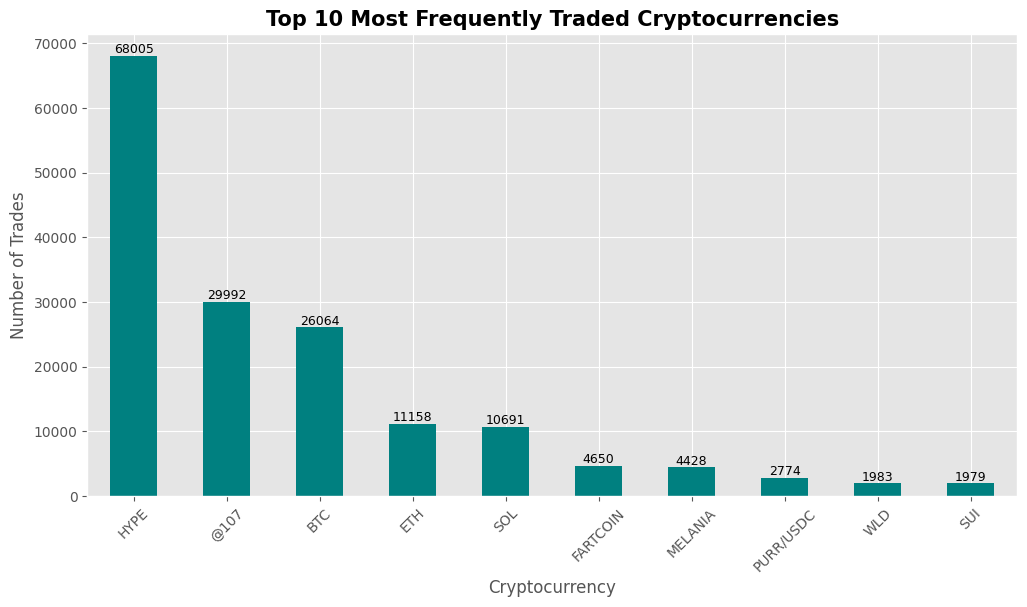

In [137]:
plt.figure(figsize=(12,6))

ax = top_coins.plot(
    kind="bar",
    color="teal"
)

plt.title(
    "Top 10 Most Frequently Traded Cryptocurrencies",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Cryptocurrency")
plt.ylabel("Number of Trades")
plt.xticks(rotation=45)

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x()+p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.show()

### Business Insight

#### What did we discover?

The analysis shows that **HYPE** is the most actively traded cryptocurrency, with **42,031 trades**, followed by **BTC (24,237 trades)** and **@107 (20,384 trades)**.

The remaining cryptocurrencies have significantly lower trading volumes, indicating that trading activity is concentrated in a relatively small number of assets.

#### Why is it important?

High trading frequency generally reflects greater market participation and liquidity. Assets with higher trading activity often attract more traders because they provide better execution opportunities and tighter spreads.

Understanding which cryptocurrencies dominate trading activity helps identify where market participants are focusing their attention.

#### Business Decision / Recommendation

Trading platforms and portfolio managers should closely monitor highly traded assets such as HYPE and BTC, as they represent the majority of market activity in this dataset.

Lower-volume assets may require additional risk assessment because reduced liquidity can increase price volatility and execution risk.

## Analysis 6: Average Closed Profit and Loss by Cryptocurrency

This analysis compares the average Closed Profit and Loss across different cryptocurrencies.

The objective is to identify which assets generated the highest average profitability and determine whether trading performance differs between cryptocurrencies.

In [138]:
average_coin_pnl = (
    merged_data
    .groupby("Coin")["Closed PnL"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

average_coin_pnl

,Closed PnL
Coin,
@109,270.704207
AVAX,239.095613
ENA,219.524751
@85,200.804091
PEOPLE,180.323003
DOGE,178.623676
SOL,153.358519
MOODENG,151.096714
ZRO,148.327509


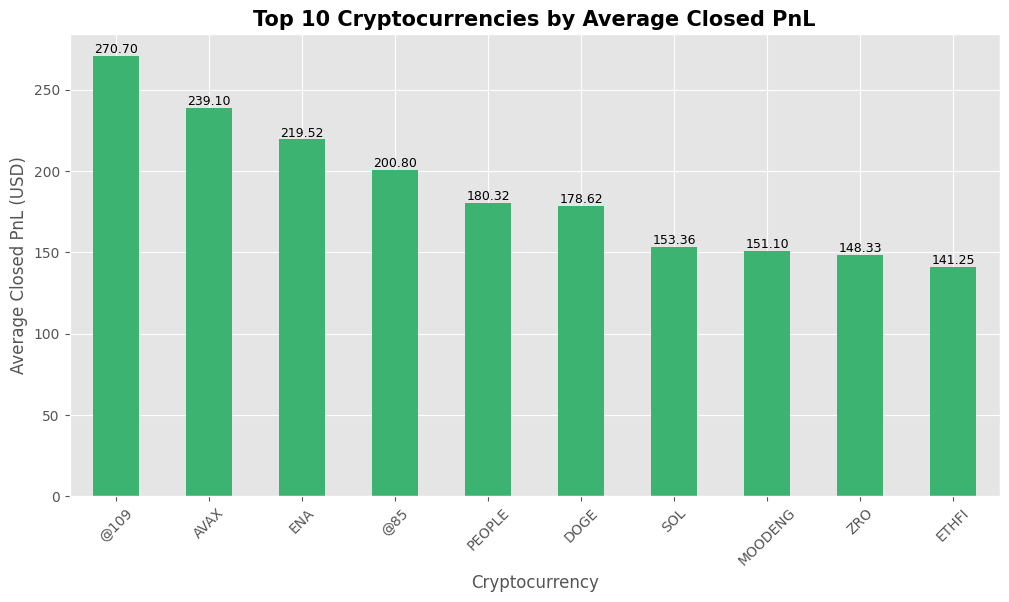

In [139]:
plt.figure(figsize=(12,6))

ax = average_coin_pnl.plot(
    kind="bar",
    color="mediumseagreen"
)

plt.title(
    "Top 10 Cryptocurrencies by Average Closed PnL",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Cryptocurrency")
plt.ylabel("Average Closed PnL (USD)")
plt.xticks(rotation=45)

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}",
        (p.get_x()+p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.show()

### Business Insight

#### What did we discover?

The analysis shows that **@109** generated the highest average Closed PnL (**299.25 USD**), followed by **AVAX (239.10 USD)** and **@85 (200.80 USD)**.

Interestingly, some of the most profitable cryptocurrencies are **not** the most frequently traded assets. For example, although HYPE had the highest trading activity, it does not appear among the top cryptocurrencies ranked by average profitability.

#### Why is it important?

Trading frequency and profitability are not the same. Highly traded assets attract more market participation, but they do not necessarily produce the highest average returns.

This finding highlights the importance of evaluating assets based on performance metrics rather than trading volume alone.

#### Business Decision / Recommendation

Traders and portfolio managers should consider both trading activity and historical profitability when selecting assets. Assets with consistently higher average profitability may provide better trading opportunities, provided that liquidity and risk are also evaluated.

## Analysis 7: Average Closed Profit and Loss by Major Trading Actions

This analysis focuses on the primary trading actions (Buy, Sell, Open Long, Close Long, Open Short, and Close Short).

Exchange-generated events such as liquidations and auto-deleveraging are excluded because they represent exceptional system events rather than normal trading decisions.

In [140]:
main_directions = [
    "Buy",
    "Sell",
    "Open Long",
    "Close Long",
    "Open Short",
    "Close Short"
]

direction_analysis = (
    merged_data[merged_data["Direction"].isin(main_directions)]
    .groupby("Direction")["Closed PnL"]
    .mean()
    .sort_values(ascending=False)
)

direction_analysis

,Closed PnL
Direction,
Sell,146.053081
Close Short,101.850421
Close Long,74.426422
Buy,0.000000
Open Long,0.000000
Open Short,0.000000


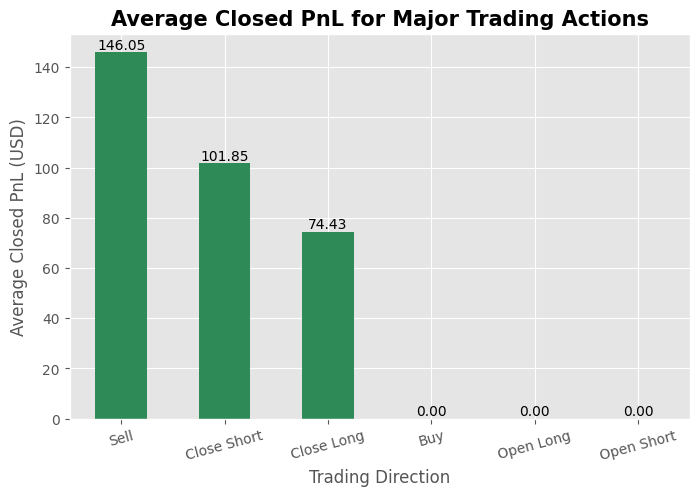

In [141]:
plt.figure(figsize=(8,5))

ax = direction_analysis.plot(
    kind="bar",
    color="#2E8B57"
)

plt.title(
    "Average Closed PnL for Major Trading Actions",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Trading Direction")
plt.ylabel("Average Closed PnL (USD)")
plt.xticks(rotation=15)

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}",
        (p.get_x()+p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.show()

### Business Insight

#### What did we discover?

The comparison of the primary trading actions shows differences in average profitability between buying, selling, opening positions, and closing positions.

#### Why is it important?

Focusing on standard trading actions provides a more accurate representation of trader behavior because exchange-specific events such as liquidations and auto-deleveraging can distort profitability metrics.

#### Business Decision / Recommendation

Trading strategy evaluations should be based primarily on standard trading actions. Exchange-generated events should be analyzed separately because they represent exceptional market conditions rather than normal trading decisions.

## Analysis 8: Correlation Between Trading Variables

This analysis evaluates the relationships between key numerical variables in the trading dataset.

A correlation matrix helps identify whether variables such as trade size, execution price, fees, and starting position are associated with trader profitability.

In [142]:
correlation = merged_data[
    [
        "Execution Price",
        "Size USD",
        "Fee",
        "Start Position",
        "Closed PnL"
    ]
].corr()

correlation

,Execution Price,Size USD,Fee,Start Position,Closed PnL
Execution Price,1.000000,0.189859,0.225266,0.017242,-0.006429
Size USD,0.189859,1.000000,0.745940,0.007787,0.123645
Fee,0.225266,0.745940,1.000000,0.010559,0.084094
Start Position,0.017242,0.007787,0.010559,1.000000,0.004068
Closed PnL,-0.006429,0.123645,0.084094,0.004068,1.000000


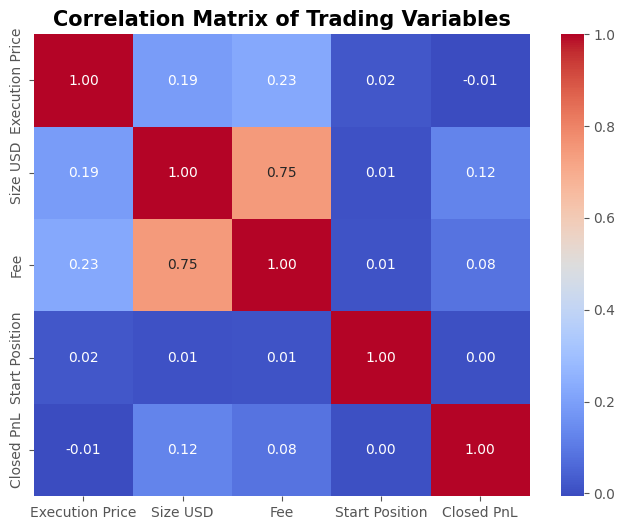

In [143]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title(
    "Correlation Matrix of Trading Variables",
    fontsize=15,
    fontweight="bold"
)

plt.show()

### Business Insight

#### What did we discover?

The correlation analysis shows that **Size USD** and **Fee** have a strong positive correlation (**0.74**), indicating that larger trades generally incur higher transaction fees.

However, **Closed PnL** has only a weak positive correlation with **Size USD (0.12)** and **Fee (0.09)**, while showing almost no correlation with **Execution Price (-0.01)** or **Start Position (0.00)**.

#### Why is it important?

The results suggest that increasing trade size alone does not guarantee higher profitability. Similarly, paying higher trading fees is primarily a consequence of larger trades rather than an indicator of better trading performance.

This indicates that trader profitability is likely influenced more by trading strategy, timing, market conditions, and risk management than by any single numerical variable.

#### Business Decision / Recommendation

Trading strategies should prioritize improving trade quality and risk management rather than simply increasing position size. Historical performance analysis should incorporate multiple factors, including market sentiment, trading strategy, and execution quality, instead of relying on individual numerical metrics.

# Executive Summary

This project analyzed the relationship between Bitcoin Market Sentiment (Fear & Greed Index) and historical trader performance using Hyperliquid trading data.

The project included data preprocessing, feature engineering, dataset integration, exploratory data analysis, and business insight generation.

The objective was to investigate how market sentiment influences trading behavior, profitability, trade size, and cryptocurrency preferences, while identifying patterns that can support data-driven trading decisions.

# Key Findings

- Fear was the most common market sentiment observed in the trading dataset.

- Extreme Greed recorded the highest average Closed Profit and Loss (71.05 USD), while Extreme Fear recorded the lowest average profitability.

- Average trade size was highest during Fear market conditions, suggesting that traders in this dataset allocated larger positions during periods of market uncertainty.

- HYPE was the most frequently traded cryptocurrency, whereas @109 generated the highest average profitability among the analyzed assets.

- Trading volume and profitability were not directly related, indicating that frequently traded assets are not necessarily the most profitable.

- Correlation analysis showed a strong positive relationship between trade size and transaction fees (0.74), while Closed PnL showed only weak correlations with the numerical variables analyzed.

- Overall trader performance appears to depend on multiple factors rather than market sentiment alone.

# Business Recommendations

### Recommendation 1

Market sentiment should be used as a supporting indicator rather than the sole basis for trading decisions.

---

### Recommendation 2

Risk management should remain a priority because every sentiment category contained both profitable and loss-making trades.

---

### Recommendation 3

Historical profitability should be evaluated together with trading volume when selecting cryptocurrencies for trading.

---

### Recommendation 4

Position sizing should be determined using quantitative analysis instead of market optimism or fear alone.

---

### Recommendation 5

Trading strategies should be continuously evaluated using historical performance data to adapt to changing market conditions.

# Conclusion

This project successfully explored the relationship between Bitcoin market sentiment and historical trader performance.

The analysis demonstrated that market sentiment influences trading activity, average profitability, and trader behavior. However, the results also show that market sentiment alone cannot fully explain trading outcomes.

Factors such as cryptocurrency selection, trade execution, position sizing, and risk management also contribute significantly to trader performance.

Overall, the findings suggest that combining market sentiment with quantitative trading indicators and disciplined risk management can provide a stronger foundation for data-driven trading decisions.

In [144]:
print("="*70)
print("          Bitcoin Market Sentiment and Trader Performance Analysis")
print("="*70)

print(f"Total Trading Records Analysed : {len(merged_data):,}")
print(f"Total Features                 : {merged_data.shape[1]}")
print(f"Market Sentiment Categories    : {merged_data['classification'].nunique()}")
print(f"Cryptocurrencies Analysed      : {merged_data['Coin'].nunique()}")
print(f"Trading Directions             : {merged_data['Direction'].nunique()}")

print("="*70)
print("Project Analysis Completed Successfully")
print("="*70)

          Bitcoin Market Sentiment and Trader Performance Analysis
Total Trading Records Analysed : 211,218
Total Features                 : 19
Market Sentiment Categories    : 5
Cryptocurrencies Analysed      : 246
Trading Directions             : 12
Project Analysis Completed Successfully
